# DEG Analysis: 10-07-2023 Run

This file includes the R analysis for the bulk sequencing data for `NS` and `NOVA` sequencing runs.



## Step 0: Load into R

**At this step, we need to change to the R kernel if we are using Jupyter for this.** (You can also just use R directly.) Make sure you install R and the packages below. We will use them at various points in the analysis.

In [441]:
library(DESeq2)
library(pheatmap)
library(data.table)
library(purrr)
library(tidyr)
library(dplyr)
library(Seurat)
library(scatterplot3d)
library(biomaRt)
library(ggplot2)
library(cowplot)

In [4]:
getwd()

[1] "/ddn/gs1/home/laispf/active-projects/srf-myocd-project/bulk-pipeline/results/run-10072023-02-pres"

## Step 1: Read in and process counts data

Load the count data into regular matrices that are amenable to principal component analysis and differential gene expression matrices.

In [99]:
# Load in the table and make sure it works/reads fine!
# There's a comment at the beginning of the counts file, so skip that first line.
filePath = "analysis/counts.txt"
cts = fread(file=filePath)
head(cts)

Geneid,Chr,Start,End,Strand,Length,run-10072023-02/aligned/processed/Ctrl1_20230502_193843.L001.bam,run-10072023-02/aligned/processed/Ctrl2_20230502_193843.L001.bam,run-10072023-02/aligned/processed/Ctrl3_20230502_193843.L001.bam,run-10072023-02/aligned/processed/Ctrl4_20230502_193843.L001.bam,run-10072023-02/aligned/processed/Srf1_20230502_193843.L001.bam,run-10072023-02/aligned/processed/Srf2_20230502_193843.L001.bam,run-10072023-02/aligned/processed/Srf3_20230502_193843.L001.bam,run-10072023-02/aligned/processed/Srf4_20230502_193843.L001.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ENSMUSG00000102693,1,3073253,3074322,+,1070,1,2,0,0,1,1,2,1
ENSMUSG00000064842,1,3102016,3102125,+,110,0,0,1,0,0,0,0,0
ENSMUSG00000051951,1;1;1;1;1;1;1,3205901;3206523;3213439;3213609;3214482;3421702;3670552,3207317;3207317;3215632;3216344;3216968;3421901;3671498,-;-;-;-;-;-;-,6094,596,129,158,218,286,207,239,143
ENSMUSG00000102851,1,3252757,3253236,+,480,0,0,0,0,0,0,0,0
ENSMUSG00000103377,1,3365731,3368549,-,2819,2,2,2,4,6,0,14,0
ENSMUSG00000104017,1,3375556,3377788,-,2233,1,2,1,4,7,1,10,0


The sample names are currently kind of gross, but that's nothing a bit of regex won't fix. We standardize the names in both the data and metadata files **and also ensure that the samples occur in the same order.** This last part is especially important because DESeq does **not** match the sample names against each other and ensures they occur in the same order and are exact matches.

**Also note** that any categorical variables must be of mode `factor`.

In [100]:
# Clean up the columns of the counts matrix.
cleanedColNames = unlist(map(strsplit(basename(colnames(cts)[7:ncol(cts)]), '_'), function (x) x[[1]]))
colnames(cts) = c(colnames(cts)[1:6], cleanedColNames)
head(cts)

Geneid,Chr,Start,End,Strand,Length,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ENSMUSG00000102693,1,3073253,3074322,+,1070,1,2,0,0,1,1,2,1
ENSMUSG00000064842,1,3102016,3102125,+,110,0,0,1,0,0,0,0,0
ENSMUSG00000051951,1;1;1;1;1;1;1,3205901;3206523;3213439;3213609;3214482;3421702;3670552,3207317;3207317;3215632;3216344;3216968;3421901;3671498,-;-;-;-;-;-;-,6094,596,129,158,218,286,207,239,143
ENSMUSG00000102851,1,3252757,3253236,+,480,0,0,0,0,0,0,0,0
ENSMUSG00000103377,1,3365731,3368549,-,2819,2,2,2,4,6,0,14,0
ENSMUSG00000104017,1,3375556,3377788,-,2233,1,2,1,4,7,1,10,0


In [119]:
# Make the DESeq counts matrix.
dcts = as.data.frame(cts[,7:ncol(cts)])
rownames(dcts) = unlist(cts[,'Geneid'])
head(dcts)

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
ENSMUSG00000102693,1,2,0,0,1,1,2,1
ENSMUSG00000064842,0,0,1,0,0,0,0,0
ENSMUSG00000051951,596,129,158,218,286,207,239,143
ENSMUSG00000102851,0,0,0,0,0,0,0,0
ENSMUSG00000103377,2,2,2,4,6,0,14,0
ENSMUSG00000104017,1,2,1,4,7,1,10,0


To also perform the differential expression analysis, DESeq needs information about certain discrete variables (factors) in each sample. I've made a metadata table below.

In [213]:
# Make a factor list between control and experimental groups.
# We can do this by just stripping the numbers out of the cleaned group names.
groups = as.factor(sub("\\d", "", cleanedColNames))
groups = relevel(groups, ref="Ctrl")
dgroups = data.frame(row.names=cleanedColNames, Group=groups)
dgroups
levels(groups)

,Group
,<fct>
Ctrl1,Ctrl
Ctrl2,Ctrl
Ctrl3,Ctrl
Ctrl4,Ctrl
Srf1,Srf
Srf2,Srf
Srf3,Srf
Srf4,Srf


[1] "Ctrl" "Srf"

A concrete check to ensure the sample names in both data and metadata files are the same and ordered the same.

In [121]:
# Ensure the data and metadata labels are within each other and in the same order.
all(rownames(groups) %in% colnames(dcts))
all(rownames(groups) == colnames(dcts))

[1] TRUE

[1] TRUE

## Step 2: Perform preliminary analysis using dimensionality reduction

Viusalize inter-group heterogeneity using PCA, a simple dimensionality reduction technique. We will expect the control (Ctrl) and experimental (Srf) groups to separate to a large degree.

In [136]:
# Normalize and center the data in advance of running PCA.
dctsProc = NormalizeData(dcts)
dctsProc = ScaleData(dctsProc)
dctsProc = as.matrix(dctsProc)
head(dctsProc, 8)

Centering and scaling data matrix



,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
ENSMUSG00000102693,-0.5214149,1.0310149,-1.2603731,-1.26037310,-0.229242514,0.07641505,1.2920721,0.8719015
ENSMUSG00000064842,-0.3535534,-0.3535534,2.4748737,-0.35355339,-0.353553391,-0.35355339,-0.3535534,-0.3535534
ENSMUSG00000051951,1.6606499,-1.6900509,-0.8037263,0.81859463,-0.001928644,-0.21023188,0.1139410,0.1127521
ENSMUSG00000102851,0.0000000,0.0000000,0.0000000,0.00000000,0.000000000,0.00000000,0.0000000,0.0000000
ENSMUSG00000103377,-0.5420603,-0.4040964,-0.3097953,0.34812064,0.256463652,-0.79270542,2.2367785,-0.7927054
ENSMUSG00000104017,-0.7489900,-0.3990720,-0.5946396,0.60065940,0.711216840,-0.61423902,1.9606158,-0.9155514
ENSMUSG00000103025,-0.7085134,0.2976233,-1.1874520,-0.09743825,-0.853296605,-0.32105158,1.2938472,1.5762814
ENSMUSG00000089699,0.0000000,0.0000000,0.0000000,0.00000000,0.000000000,0.00000000,0.0000000,0.0000000


In [137]:
# Calculate principal components. Note that things have already been centered and scaled.
pca_results = prcomp(t(dctsProc))
pca_results$x

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Ctrl1,-66.400733,70.49319,1.888480e+00,127.39211,11.789712,62.95400,81.707174,8.523108e-14
Ctrl2,-109.861873,-16.43957,6.539802e-03,25.53142,108.081480,1.03914,-110.421782,1.682682e-14
Ctrl3,-78.847076,-70.32415,2.186337e+00,-31.93625,-123.878279,88.75654,-40.903778,2.074209e-14
Ctrl4,-92.556317,-132.51304,-2.399614e+01,-44.40537,26.708932,-74.33412,86.479636,1.949309e-14
Srf1,-1.989444,119.59025,9.946644e+01,-120.91503,27.046092,17.34485,26.524630,2.307529e-14
Srf2,16.916044,64.84333,2.694213e+01,51.71830,-83.646771,-130.81612,-35.951031,4.426060e-14
Srf3,230.380896,-94.86580,6.811449e+01,33.40270,26.249041,23.99269,-3.942246,-1.224298e-13
Srf4,102.358503,59.21578,-1.746083e+02,-40.78787,7.649793,11.06302,-3.492603,-7.861767e-14


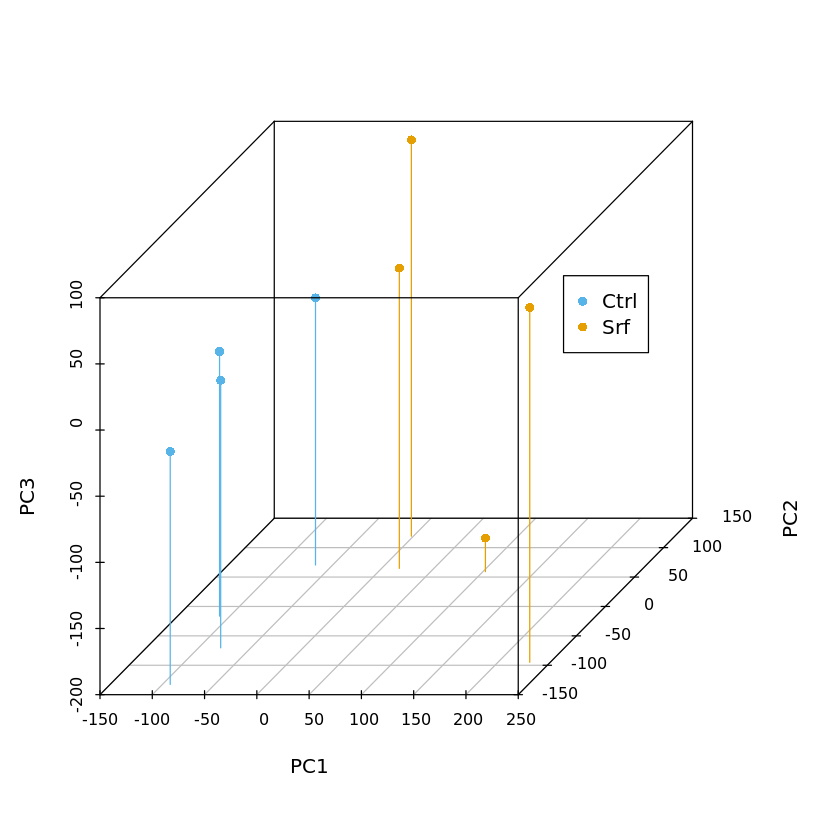

In [141]:
# Make a scatterplot with the 3D PCA data.
# To help pinpoint them in 3D space, I project them down to the XY plane as well.
colors_reference = c("#56B4E9", "#E69F00")
legend = c("Ctrl", "Srf")
color_indices = as.numeric(startsWith(rownames(pca_results$x[,1:3]), 'Srf')) + 1
colors = colors_reference[color_indices]

plt = scatterplot3d(pca_results$x[,1:3], color=colors, pch=16, type="h")

legend(plt$xyz.convert(210, 0, 50), legend=legend, col=colors_reference, pch = 16)

## Step 3: Run DESeq2

Make the DESeq dataset...

In [129]:
# Make the DESeqDataSet and analyze.
dds = DESeqDataSetFromMatrix(countData = dcts,
                             colData = dgroups,
                             design = ~ Group)
dds

class: DESeqDataSet 
dim: 55487 8 
metadata(1): version
assays(1): counts
rownames(55487): ENSMUSG00000102693 ENSMUSG00000064842 ...
  ENSMUSG00000096730 ENSMUSG00000095742
rowData names(0):
colnames(8): Ctrl1 Ctrl2 ... Srf3 Srf4
colData names(1): Group

... and perform differential expression analysis.

In [130]:
dds = DESeq(dds)
res = results(dds)
res

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



log2 fold change (MLE): Group Srf vs Ctrl 
Wald test p-value: Group Srf vs Ctrl 
DataFrame with 55487 rows and 6 columns
                      baseMean log2FoldChange     lfcSE      stat    pvalue
                     <numeric>      <numeric> <numeric> <numeric> <numeric>
ENSMUSG00000102693    0.958744      1.0594907  1.905074  0.556141  0.578114
ENSMUSG00000064842    0.142588     -0.5479298  3.533812 -0.155053  0.876779
ENSMUSG00000051951  227.848950     -0.0510681  0.321263 -0.158960  0.873700
ENSMUSG00000102851    0.000000             NA        NA        NA        NA
ENSMUSG00000103377    3.532232      0.8536916  1.463185  0.583448  0.559592
...                        ...            ...       ...       ...       ...
ENSMUSG00000094431    0.408203       1.302883  3.495739  0.372706 0.7093673
ENSMUSG00000094621    4.401664       3.296028  1.651589  1.995671 0.0459698
ENSMUSG00000098647    0.000000             NA        NA        NA        NA
ENSMUSG00000096730    0.376028       0.8786

## Step 4: Generate DEG list

To facilitate the export and analysis of these data in other programs, generate a list of highly differentially expressed genes.

We also do the following to include a filtered gene expression list: list everything with p-adjusted < 0.05, sort by least p-value, FC > abs(1.5), and package it into a CSV.

In [242]:
# Carry out the above instructions.
testCounts = counts(dds)
testCounts = cbind(testCounts, res[['padj']], 2 ** res[['log2FoldChange']])
colnames(testCounts) = c(colnames(testCounts)[1:8], 'padj', 'FC')
testCountsdf = as.data.frame(testCounts)
testCountsdf = testCountsdf[!is.na(testCountsdf[['FC']]),]
head(testCountsdf)

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4,padj,FC
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000102693,1,2,0,0,1,1,2,1,NA,2.0841956
ENSMUSG00000064842,0,0,1,0,0,0,0,0,NA,0.6840009
ENSMUSG00000051951,596,129,158,218,286,207,239,143,0.9473391,0.9652214
ENSMUSG00000103377,2,2,2,4,6,0,14,0,NA,1.8071191
ENSMUSG00000104017,1,2,1,4,7,1,10,0,NA,1.9854250
ENSMUSG00000103025,2,4,0,2,1,2,6,4,NA,1.9889701


In [243]:
temp = testCountsdf[['FC']]
temp[temp < 1] = -1 / temp[temp < 1]
testCountsdf[['FC']] = temp
head(testCountsdf)

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4,padj,FC
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSMUSG00000102693,1,2,0,0,1,1,2,1,NA,2.084196
ENSMUSG00000064842,0,0,1,0,0,0,0,0,NA,-1.461986
ENSMUSG00000051951,596,129,158,218,286,207,239,143,0.9473391,-1.036032
ENSMUSG00000103377,2,2,2,4,6,0,14,0,NA,1.807119
ENSMUSG00000104017,1,2,1,4,7,1,10,0,NA,1.985425
ENSMUSG00000103025,2,4,0,2,1,2,6,4,NA,1.988970


In [316]:
testCountsThresholdeddf = subset(testCountsdf, padj < 0.05 & abs(FC) > 1.5)
testCountsThresholdeddf = testCountsThresholdeddf[order(testCountsThresholdeddf[['FC']], decreasing=TRUE),]

# Add in MGI symbol column. We used ensembl version 102 for this.
ensembl = useEnsembl(biomart="genes", dataset="mmusculus_gene_ensembl", version=102)

mapperTable = subset(getBM(c('ensembl_gene_id', 'mgi_symbol'), mart=ensembl), mgi_symbol!="")
mapper = mapperTable[['mgi_symbol']]
names(mapper) = mapperTable[['ensembl_gene_id']]

geneMapper = function(ensembl_id) {
    if (!(ensembl_id %in% names(mapper))) return(ensembl_id)
    else return(mapper[ensembl_id])
}

testCountsThresholdeddf[['MGI-Symbol']] = map(rownames(testCountsThresholdeddf), geneMapper)

head(testCountsThresholdeddf)
tail(testCountsThresholdeddf)
nrow(testCountsThresholdeddf)

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4,padj,FC,MGI-Symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<list>
ENSMUSG00000042212,2,0,1,3,5177,1061,4269,806,2.107361e-30,1865.3173,Sprr2d
ENSMUSG00000026984,16,6,1,0,6310,2340,5822,1285,9.951851e-30,871.7282,Il1f6
ENSMUSG00000050092,22,0,4,6,6317,2390,8709,1618,4.011551e-25,711.3005,Sprr2b
ENSMUSG00000076666,0,0,1,0,414,16,129,0,3.135388e-03,414.4489,Ighv14-4
ENSMUSG00000095335,0,0,0,0,123,8,55,50,4.233517e-09,344.9941,Igkv3-5
ENSMUSG00000095753,0,1,2,0,269,117,289,0,1.129600e-03,199.0614,Igkv4-53


,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4,padj,FC,MGI-Symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<list>
ENSMUSG00000088891,9,14,7,8,0,0,0,0,2.123080e-03,-46.14428,Gm22516
ENSMUSG00000116324,1,28,4,5,0,0,0,0,1.756157e-02,-46.87920,Gm33696
ENSMUSG00000085896,37,4,8,7,0,0,0,0,1.628658e-03,-56.53751,5330429C....
ENSMUSG00000034339,1,9,18,39,0,0,1,0,2.619808e-03,-61.13941,Cstdc7
ENSMUSG00000106947,0,28,45,20,0,0,0,1,1.792069e-03,-79.18181,1700025A....
ENSMUSG00000116659,128,14,14,4,0,0,0,0,2.624503e-05,-142.05835,Gm6551


[1] 3303

In [518]:
# Output results to a CSV
fwrite(testCountsThresholdeddf, "./analysis/topDEGs-posNeg.csv", row.names=TRUE)